In [79]:
import pandas as pd
import numpy as np
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Insert your FRED API key
fred = Fred(api_key='7c555b88e31520b011cc33e23aba5fb8')

# Define date range
start_date = '2009-11-01'
end_date = '2024-12-31'

# Target variable: WTI crude oil price
wti = fred.get_series('DCOILWTICO', start_date, end_date)

In [80]:
import yfinance as yf

start_date = "2009-11-01"
end_date = "2024-12-31"

# Gold futures (COMEX)
gold = yf.download("GC=F", start=start_date, end=end_date)

# Use adjusted close (or Close)
gold_series = gold["Close"]["GC=F"]

print(gold_series)

[*********************100%***********************]  1 of 1 completed

Date
2009-11-02    1053.400024
2009-11-03    1084.300049
2009-11-04    1086.699951
2009-11-05    1088.699951
2009-11-06    1095.099976
                 ...     
2024-12-23    2612.300049
2024-12-24    2620.000000
2024-12-26    2638.800049
2024-12-27    2617.199951
2024-12-30    2606.100098
Name: GC=F, Length: 3812, dtype: float64


In [81]:
ovx = yf.download("^OVX", start="2009-11-01", end="2024-12-31")
oil_volatility = ovx['Close']['^OVX']
oil_volatility

[*********************100%***********************]  1 of 1 completed


Date
2009-11-02    41.779999
2009-11-03    41.580002
2009-11-04    40.599998
2009-11-05    38.980000
2009-11-06    38.700001
                ...    
2024-12-23    30.160000
2024-12-24    30.350000
2024-12-26    30.010000
2024-12-27    30.209999
2024-12-30    30.770000
Name: ^OVX, Length: 3815, dtype: float64

In [82]:
# Interest Rates
y3 = fred.get_series('DGS3', start_date, end_date)   # 3-Year Treasury
y10 = fred.get_series('DGS10', start_date, end_date) # 10-Year Treasury

# Yield Spread (10Y - 3Y)
yield_spread = y10 - y3

# Industrial Production
indpro = fred.get_series('INDPRO', "2009-11-01", end_date)

In [83]:
yield_spread

2009-11-02    2.01
2009-11-03    2.04
2009-11-04    2.11
2009-11-05    2.13
2009-11-06    2.14
              ... 
2024-12-25     NaN
2024-12-26    0.23
2024-12-27    0.26
2024-12-30    0.26
2024-12-31    0.31
Length: 3957, dtype: float64

In [84]:
indpro

2009-11-01     88.0221
2009-12-01     88.3793
2010-01-01     89.3426
2010-02-01     89.6779
2010-03-01     90.2928
                ...   
2024-08-01    100.4309
2024-09-01     99.8084
2024-10-01     99.4695
2024-11-01     99.2925
2024-12-01    100.3273
Length: 182, dtype: float64

In [85]:
# S&P 500 index
#sp500 = fred.get_series('SP500', start_date, end_date)

# VIX volatility index
vix = fred.get_series('VIXCLS', start_date, end_date)

# USD index (Trade Weighted Dollar Index)
usd = fred.get_series('DTWEXBGS', start_date, end_date)



In [86]:
sp500 = yf.download("^GSPC", start=start_date, end=end_date)
sp500=sp500["Close"]['^GSPC']
sp500

[*********************100%***********************]  1 of 1 completed


Date
2009-11-02    1042.880005
2009-11-03    1045.410034
2009-11-04    1046.500000
2009-11-05    1066.630005
2009-11-06    1069.300049
                 ...     
2024-12-23    5974.069824
2024-12-24    6040.040039
2024-12-26    6037.589844
2024-12-27    5970.839844
2024-12-30    5906.939941
Name: ^GSPC, Length: 3815, dtype: float64

- The S&P 500 (Standard & Poor's 500 Index) is a market-capitalization-weighted index tracking 500 of the largest publicly traded U.S. companies. It is a premier benchmark for the overall health of the US economy and stock market, representing roughly 80% of the total market value.
- The CBOE Volatility Index (VIX) is a real-time market index that acts as a "fear gauge," measuring expected 30-day volatility for the S&P 500 index. It predicts market risk and investor sentiment by tracking options prices, usually moving inversely to the S&P 500—rising during uncertainty and falling during stability
- West Texas Intermediate (WTI) is a high-quality, light, and sweet crude oil that serves as a primary benchmark for oil pricing in the United States
- The U.S. Dollar Index (DXY) is a measure of the value of the U.S. dollar relative to a basket of six major foreign currencies: the Euro (EUR), Japanese Yen (JPY), British Pound (GBP), Canadian Dollar (CAD), Swedish Krona (SEK), and Swiss Franc (CHF)
- Crude oil inventory refers to the total stock of unrefined petroleum currently stored in tanks, pipelines, and terminals by producing nations, refiners, and commercial operators.


In [87]:
for df in [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

In [88]:
data = pd.concat(
    [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility],
    axis=1,
    join='outer'
)

In [89]:
data.columns = ['WTI', 'SP500', 'VIX', 'USD', "Gold", "Yield", "Oil_Volatility"]
data

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility
2009-11-02,78.08,1042.880005,29.78,92.4501,1053.400024,2.01,41.779999
2009-11-03,79.58,1045.410034,28.81,92.9037,1084.300049,2.04,41.580002
2009-11-04,80.30,1046.500000,27.72,92.3725,1086.699951,2.11,40.599998
2009-11-05,79.64,1066.630005,25.43,92.3437,1088.699951,2.13,38.980000
2009-11-06,77.40,1069.300049,24.19,92.3848,1095.099976,2.14,38.700001
...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999
2024-12-30,71.73,5906.939941,17.40,128.8205,2606.100098,0.26,30.770000


In [90]:
indpro_release = indpro.copy()

# shift to end of month
indpro_release.index = indpro_release.index + pd.offsets.MonthEnd(0)

# add ~15 days release lag (approximation)
indpro_release.index = indpro_release.index + pd.Timedelta(days=15)

data['INDPRO'] = indpro_release.reindex(data.index).ffill()

In [91]:
indpro_release

2009-12-15     88.0221
2010-01-15     88.3793
2010-02-15     89.3426
2010-03-15     89.6779
2010-04-15     90.2928
                ...   
2024-09-15    100.4309
2024-10-15     99.8084
2024-11-15     99.4695
2024-12-15     99.2925
2025-01-15    100.3273
Length: 182, dtype: float64

In [92]:
data.index.name = "Date"
data

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility,INDPRO
Date,,,,,,,,
2009-11-02,78.08,1042.880005,29.78,92.4501,1053.400024,2.01,41.779999,NaN
2009-11-03,79.58,1045.410034,28.81,92.9037,1084.300049,2.04,41.580002,NaN
2009-11-04,80.30,1046.500000,27.72,92.3725,1086.699951,2.11,40.599998,NaN
2009-11-05,79.64,1066.630005,25.43,92.3437,1088.699951,2.13,38.980000,NaN
2009-11-06,77.40,1069.300049,24.19,92.3848,1095.099976,2.14,38.700001,NaN
...,...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.4695
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000,99.4695
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999,99.4695


In [93]:
#get data just from 2010
data=data.loc[data.index>"2009-12-31"]
data

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility,INDPRO
Date,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0221
2010-01-04,81.52,1132.989990,20.04,92.3566,1117.699951,2.19,35.439999,88.0221
2010-01-05,81.74,1136.520020,19.35,92.2236,1118.099976,2.20,34.270000,88.0221
2010-01-06,83.12,1137.140015,19.16,92.0941,1135.900024,2.25,34.400002,88.0221
2010-01-07,82.60,1141.689941,19.06,92.3684,1133.099976,2.23,33.610001,88.0221
...,...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.4695
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000,99.4695
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999,99.4695


In [69]:
data.to_csv("wti_data.csv", index=True)

In [97]:
# Replace inf values first
data = data.replace([np.inf, -np.inf], np.nan)

# Remove invalid non-positive values
data.loc[data['WTI'] <= 0, 'WTI'] = np.nan
data.loc[data['SP500'] <= 0, 'SP500'] = np.nan
data.loc[data['USD'] <= 0, 'USD'] = np.nan
data.loc[data['Gold'] <= 0, 'Gold'] = np.nan
data.loc[data['VIX'] <= 0, 'VIX'] = np.nan
data.loc[data['Oil_Volatility'] <= 0, 'Oil_Volatility'] = np.nan

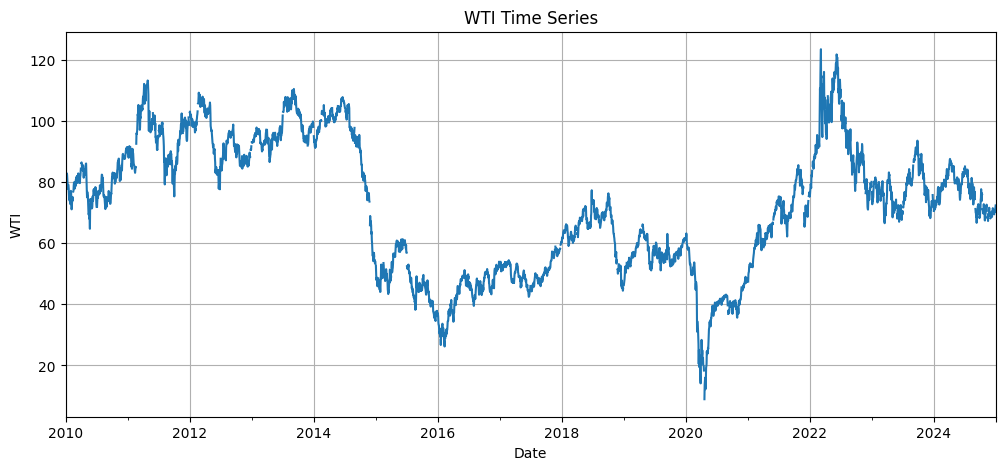

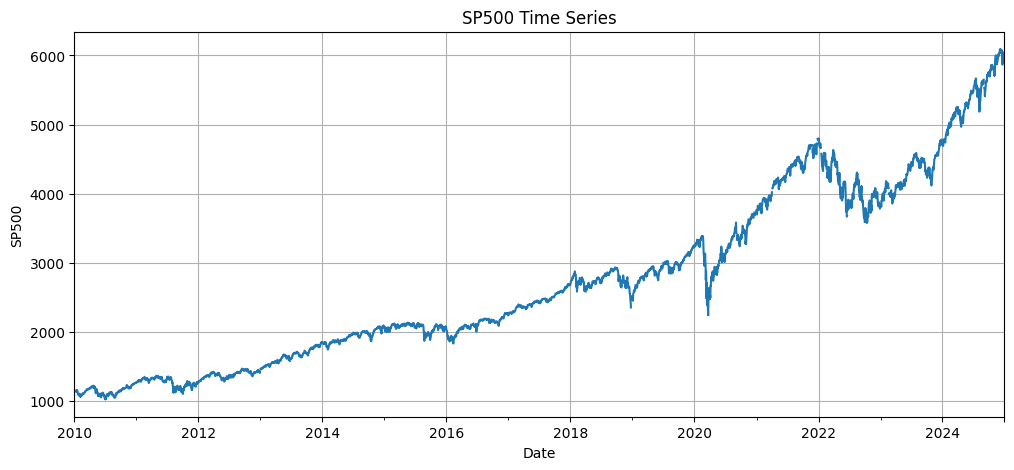

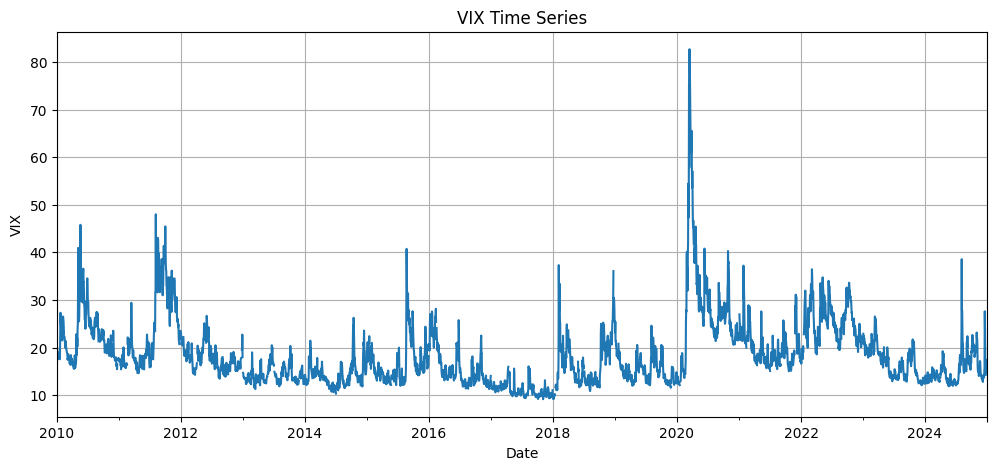

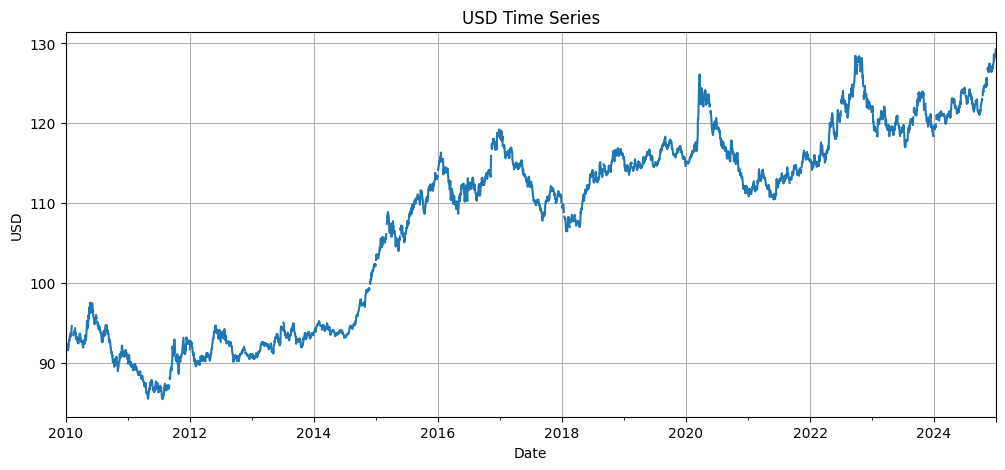

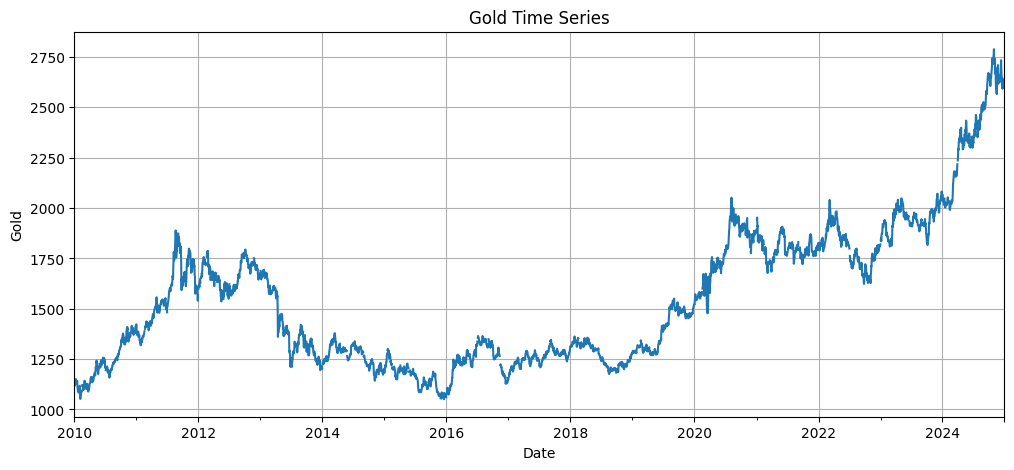

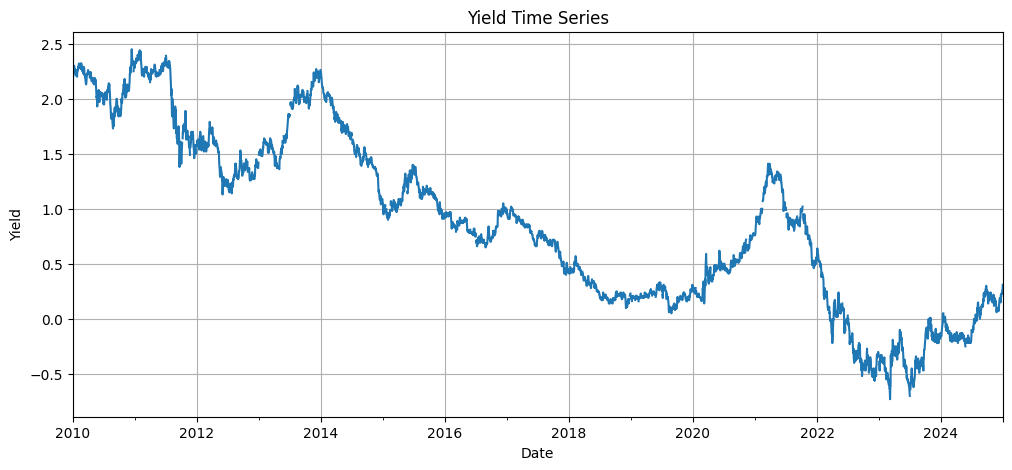

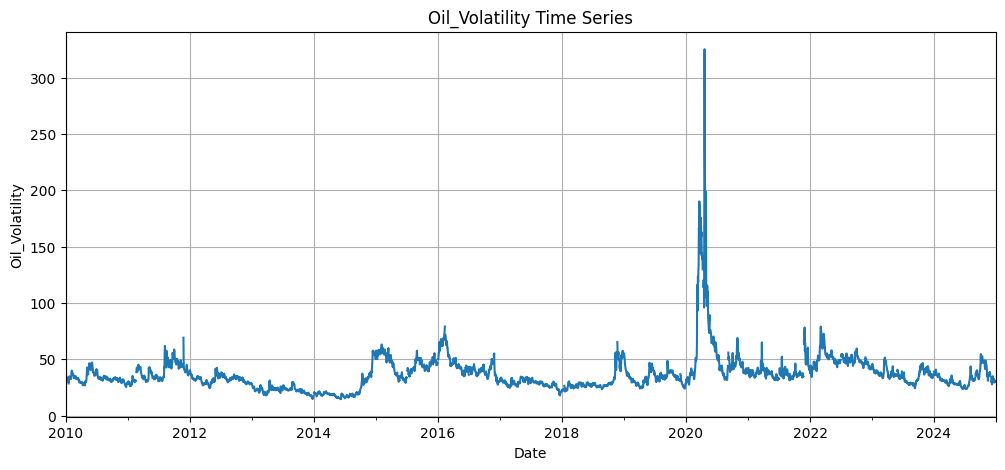

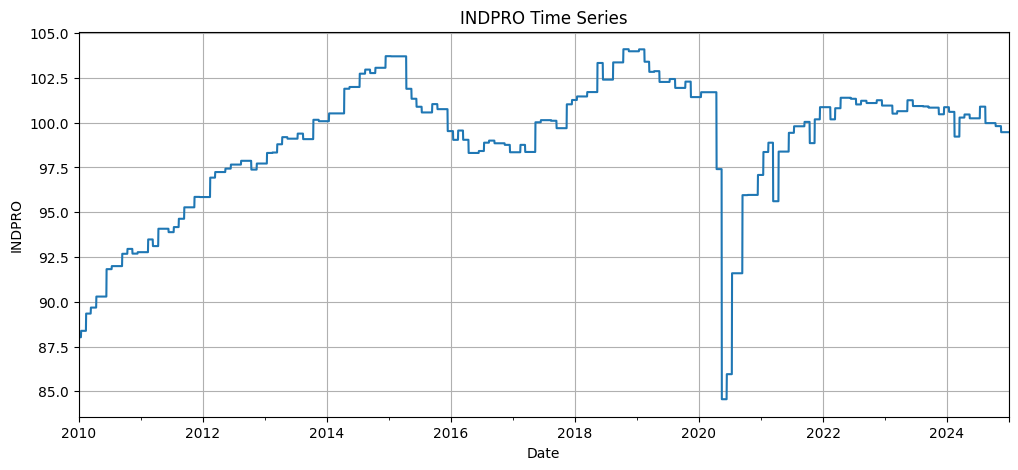

In [98]:
import matplotlib.pyplot as plt

for col in data.columns:
    plt.figure(figsize=(12, 5))
    
    data[col].plot()
    
    plt.title(f"{col} Time Series")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)
    
    plt.show()

In [ ]:
# =========================
# 1. Sort data
# =========================
data = data.sort_index()

# =========================
# 2. Remove duplicates
# =========================
data = data[~data.index.duplicated(keep='first')]

# =========================
# 3. Convert to numeric
# =========================
data = data.apply(pd.to_numeric, errors='coerce')

# =========================
# 4. Convert to weekly frequency
# =========================
data_weekly = data.resample('W-FRI').last()

# =========================
# 5. Handle missing values
# =========================
# Forward-fill small gaps
data_weekly = data_weekly.ffill(limit=2)

# Remove remaining missing rows
data_weekly = data_weekly.dropna()

# =========================
# LOG RETURNS
# =========================
returns = pd.DataFrame()

returns['WTI'] = np.log(data_weekly['WTI'] / data_weekly['WTI'].shift(1))
returns['SP500'] = np.log(data_weekly['SP500'] / data_weekly['SP500'].shift(1))
returns['USD'] = np.log(data_weekly['USD'] / data_weekly['USD'].shift(1))
returns['Gold'] = np.log(data_weekly['Gold'] / data_weekly['Gold'].shift(1))

# =========================
# DIFFERENCES
# =========================
returns['VIX_diff'] = data_weekly['VIX'].diff()
returns['OVX_diff'] = data_weekly['Oil_Volatility'].diff()
returns['Yield_diff'] = data_weekly['Yield'].diff()

# =========================
# PERCENTAGE CHANGE
# =========================
returns['INDPRO_pct'] = data_weekly['INDPRO'].pct_change()

# =========================
# LAGGED FEATURES
# =========================
returns['WTI_lag1'] = returns['WTI'].shift(1)
returns['WTI_lag2'] = returns['WTI'].shift(2)

# =========================
# TARGET VARIABLE
# =========================
returns['Target'] = returns['WTI'].shift(-1)

# =========================
# FINAL DATASET
# =========================
model_data = returns.dropna()

In [ ]:
model_data

,WTI,SP500,USD,Gold,VIX_diff,OVX_diff,Yield_diff,INDPRO_pct,WTI_lag1,WTI_lag2,Target
Date,,,,,,,,,,,
2010-01-29,-0.019035,-0.016522,0.008792,-0.005708,-2.69,-0.799999,2.000000e-02,0.0000,-0.048758,-0.059507,-0.023612
2010-02-05,-0.023612,-0.007177,0.009109,-0.028852,1.49,5.940002,6.000000e-02,0.0000,-0.019035,-0.048758,0.040760
2010-02-12,0.040760,0.008703,-0.006619,0.034836,-3.38,-3.950001,4.440892e-16,0.0000,-0.023612,-0.019035,0.073597
2010-02-19,0.073597,0.030817,-0.000433,0.028770,-2.71,-1.410000,-4.000000e-02,0.0109,0.040760,-0.023612,-0.000627
2010-02-26,-0.000627,-0.004228,-0.003163,-0.002679,-0.52,-1.810001,-2.000000e-02,0.0000,0.073597,0.040760,0.022083
...,...,...,...,...,...,...,...,...,...,...,...
2024-11-29,-0.048888,0.010505,-0.007018,-0.019714,-1.73,-0.790001,-1.000000e-02,0.0000,0.062606,-0.048698,0.004677
2024-12-06,0.004677,0.009551,0.000854,-0.006949,-0.74,-3.970001,2.000000e-02,0.0000,-0.048888,0.062606,0.042256
2024-12-13,0.042256,-0.006454,0.004895,0.006573,1.04,3.939999,9.000000e-02,0.0000,0.004677,-0.048888,-0.025913


In [75]:
data_weekly.isna().sum()

WTI               0
SP500             0
VIX               0
USD               0
Gold              0
Yield             0
Oil_Volatility    0
INDPRO            0
dtype: int64

In [76]:
z_scores = (returns - returns.mean()) / returns.std()

outliers = np.abs(z_scores) > 4

outlier_counts = outliers.sum()

print(outlier_counts)

WTI           4
SP500         5
USD           2
Gold          3
VIX_diff      5
OVX_diff      9
Yield_diff    2
INDPRO_pct    6
WTI_lag1      4
WTI_lag2      4
Target        4
dtype: int64


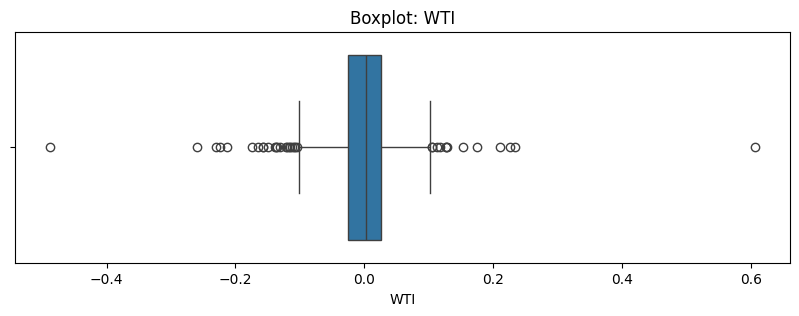

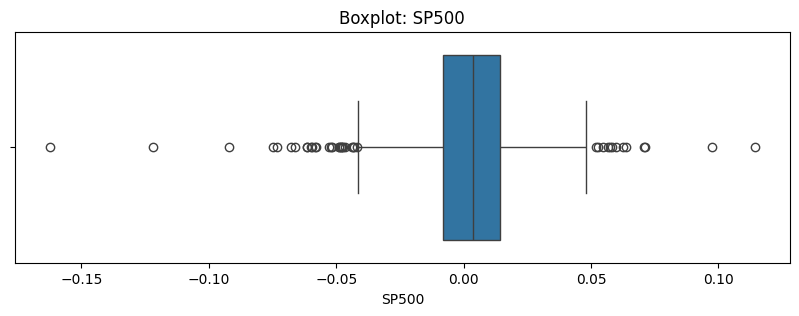

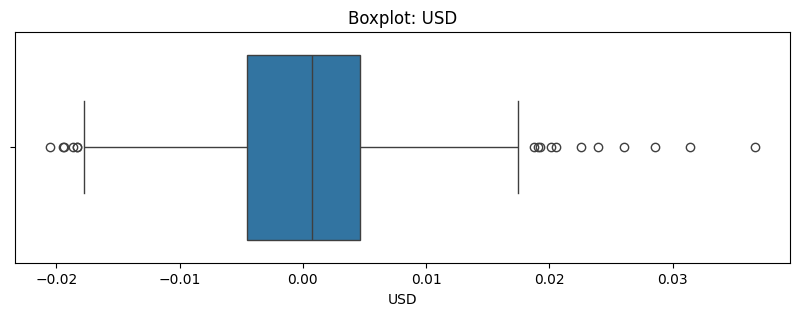

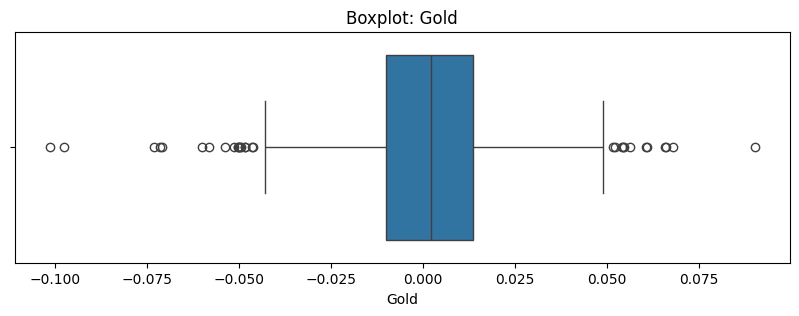

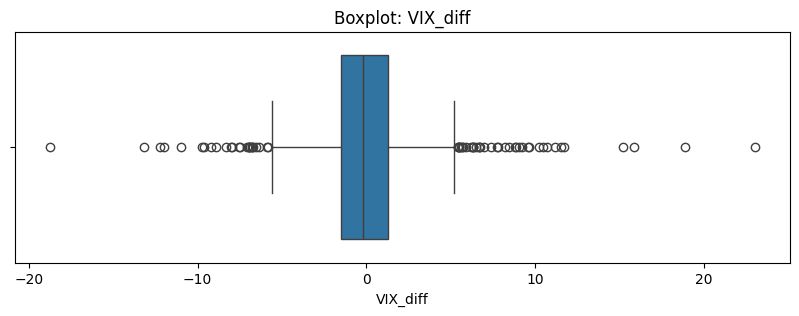

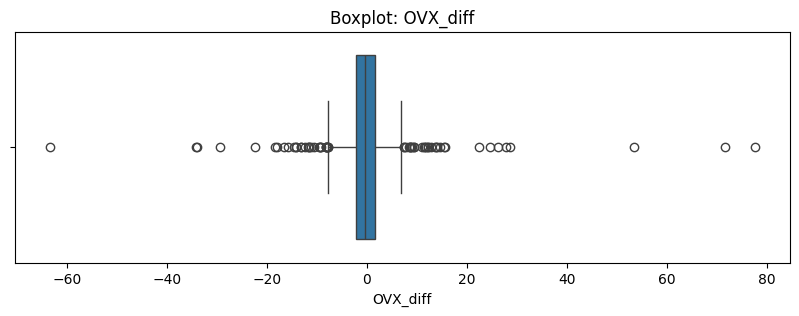

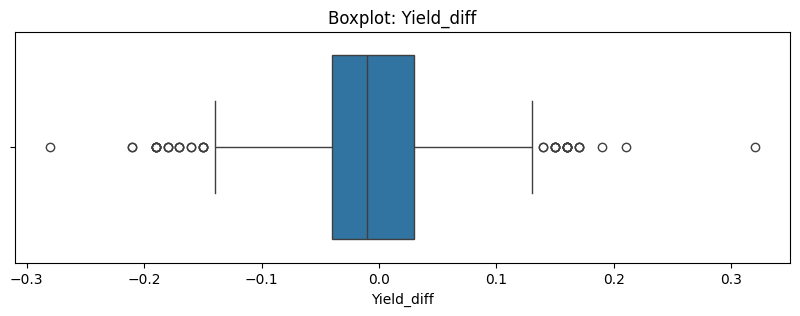

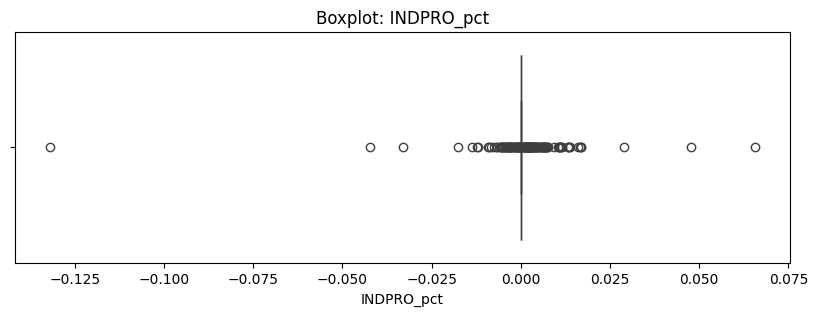

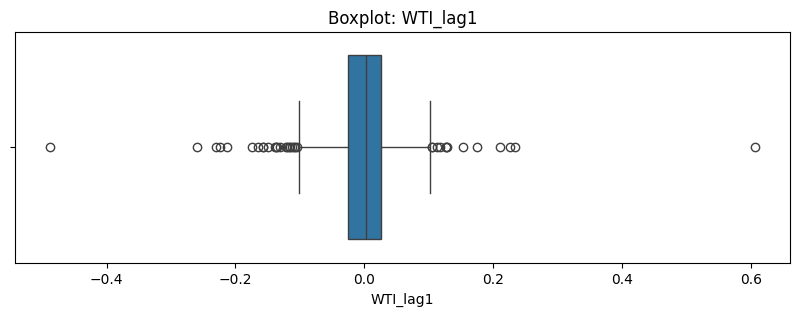

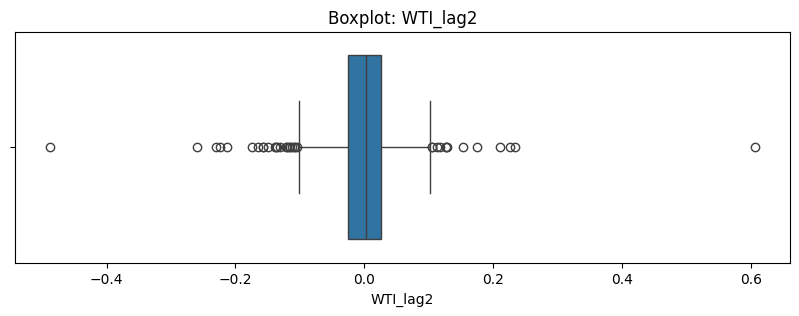

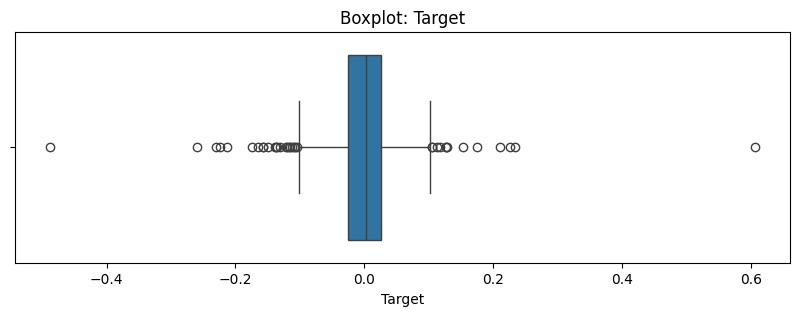

In [108]:
for col in model_data.columns:
    plt.figure(figsize=(10,3))
    
    sns.boxplot(x=model_data[col])
    
    plt.title(f'Boxplot: {col}')
    plt.show()

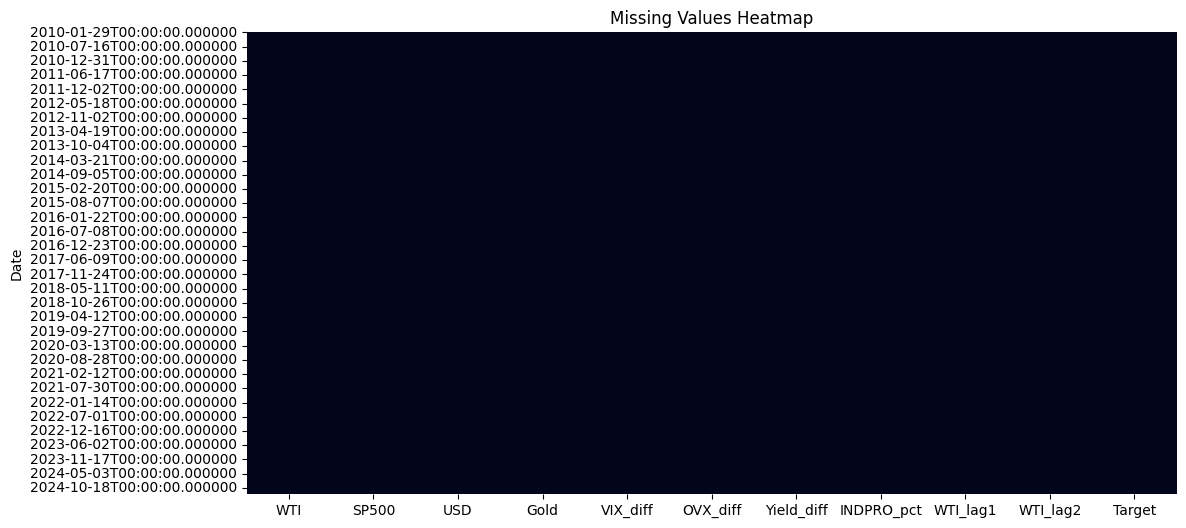

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(model_data.isna(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [103]:
model_data.index.duplicated().sum()

np.int64(0)

In [104]:
model_data.dtypes

WTI           float64
SP500         float64
USD           float64
Gold          float64
VIX_diff      float64
OVX_diff      float64
Yield_diff    float64
INDPRO_pct    float64
WTI_lag1      float64
WTI_lag2      float64
Target        float64
dtype: object

In [105]:
summary = model_data.describe().T

summary['skew'] = model_data.skew()
summary['kurtosis'] = model_data.kurtosis()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
WTI,779.0,-0.000052,0.057729,-0.487559,-0.025124,0.002533,0.026348,0.605431,0.438074,23.178488
SP500,779.0,0.002181,0.022587,-0.162279,-0.008079,0.003653,0.014359,0.114237,-0.789971,6.360198
USD,779.0,0.000415,0.007183,-0.020503,-0.004510,0.000787,0.004604,0.036661,0.386339,1.523635
Gold,779.0,0.001125,0.021376,-0.101316,-0.010098,0.002125,0.013557,0.090090,-0.275456,1.887471
VIX_diff,779.0,-0.014583,3.335876,-18.740000,-1.480000,-0.190000,1.265000,23.030000,0.767549,7.729657
OVX_diff,779.0,-0.005956,6.966134,-63.349998,-2.065000,-0.250000,1.695001,77.619995,2.648541,48.823570
Yield_diff,779.0,-0.002529,0.064769,-0.280000,-0.040000,-0.010000,0.030000,0.320000,0.051025,1.827119
INDPRO_pct,779.0,0.000174,0.006510,-0.131878,0.000000,0.000000,0.000000,0.065530,-9.253524,237.353238
WTI_lag1,779.0,-0.000144,0.057750,-0.487559,-0.025228,0.002520,0.026348,0.605431,0.441502,23.144217
WTI_lag2,779.0,-0.000187,0.057781,-0.487559,-0.025228,0.002520,0.026348,0.605431,0.441736,23.089394


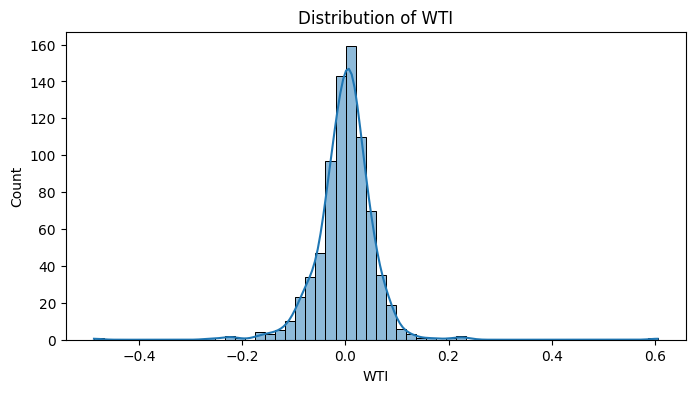

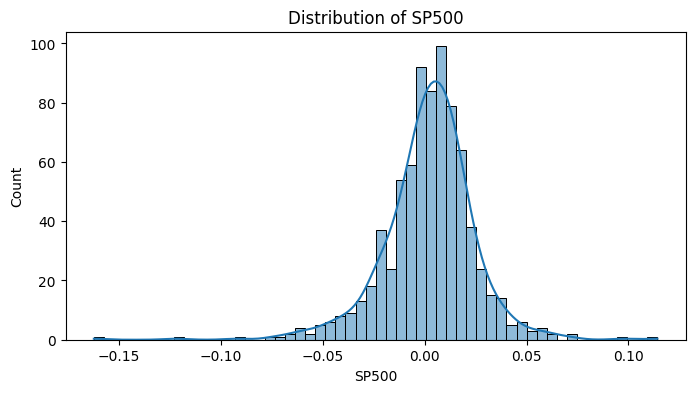

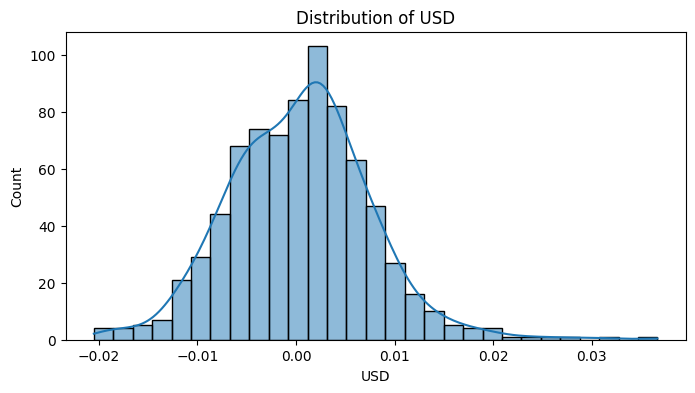

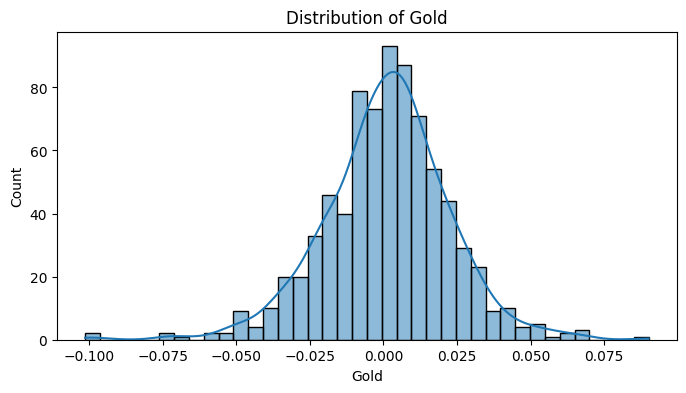

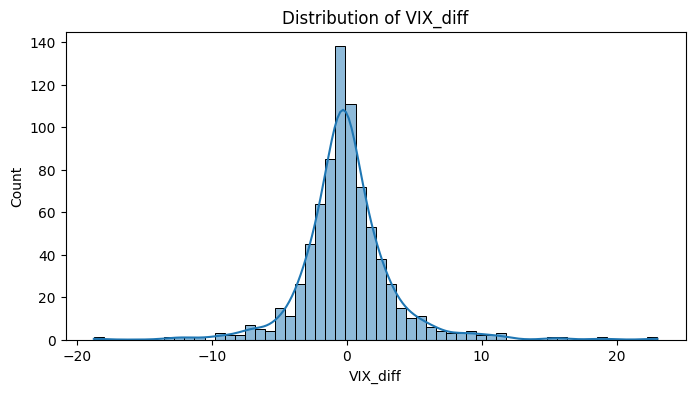

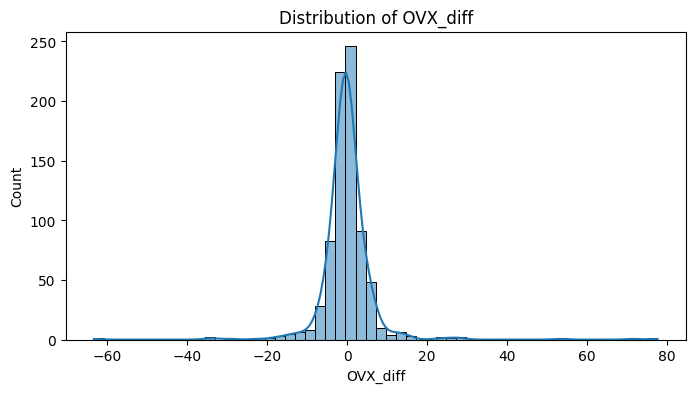

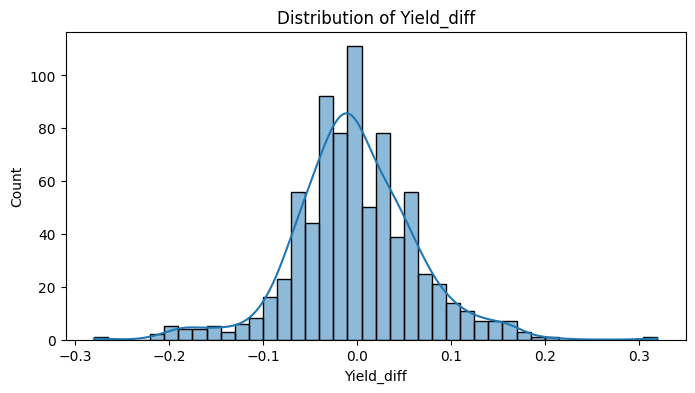

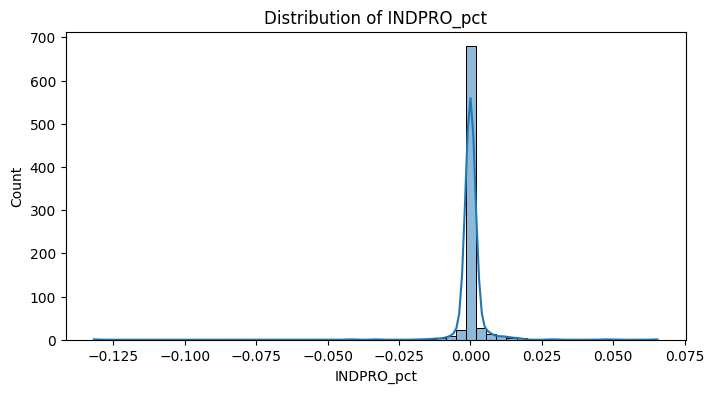

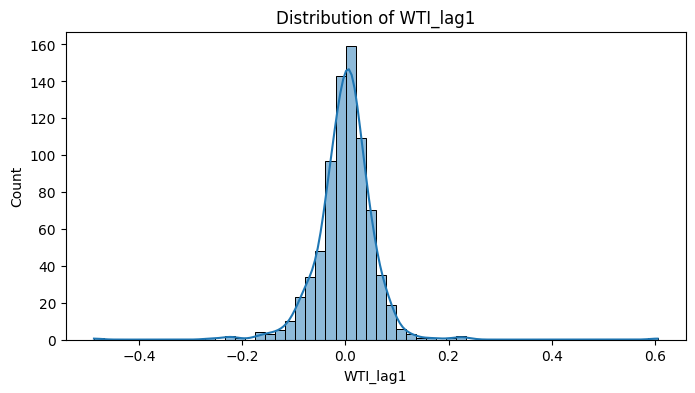

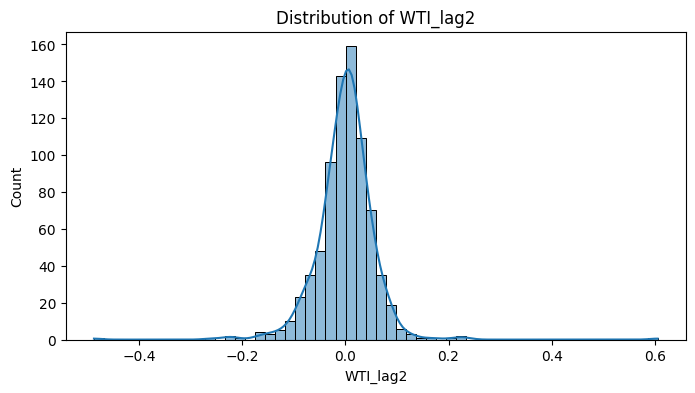

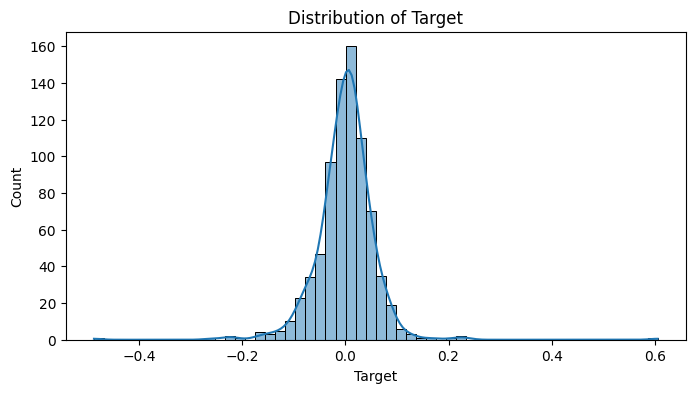

In [106]:
for col in model_data.columns:
    plt.figure(figsize=(8,4))
    
    sns.histplot(model_data[col], kde=True)
    
    plt.title(f'Distribution of {col}')
    plt.show()

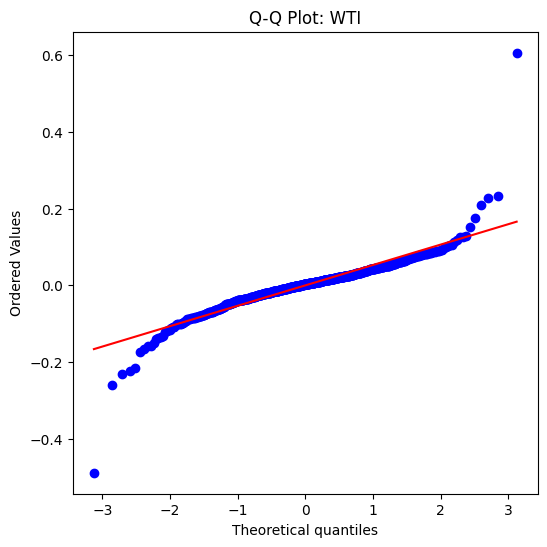

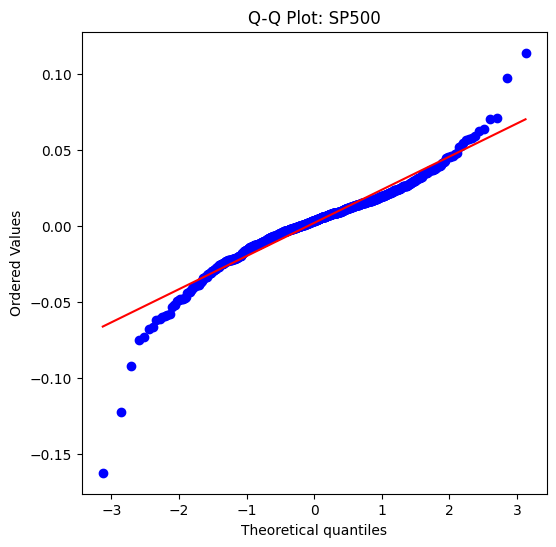

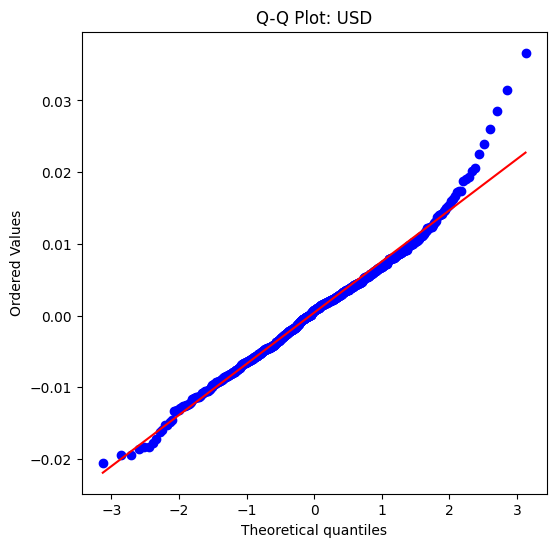

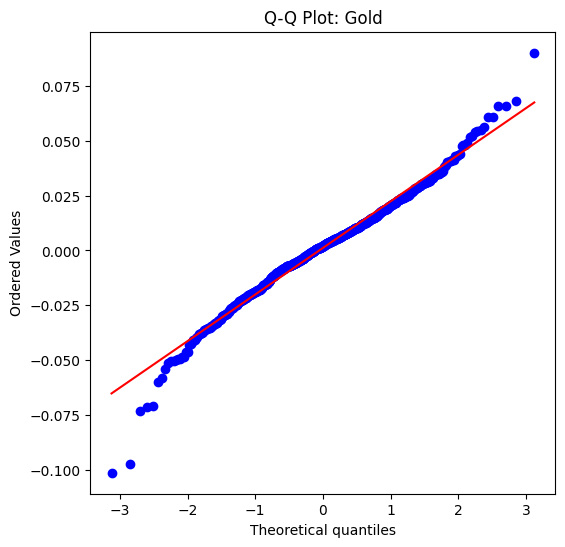

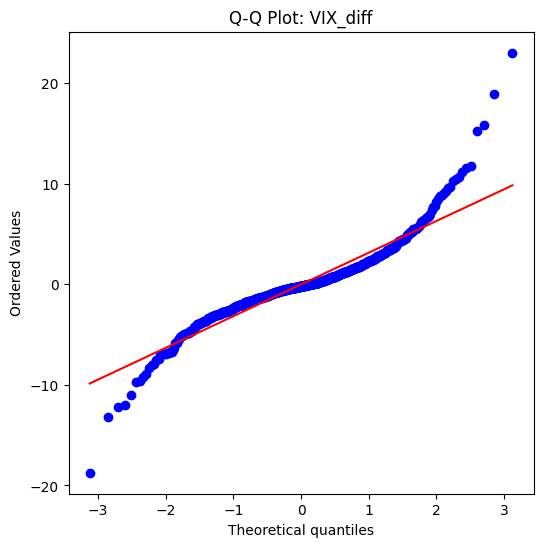

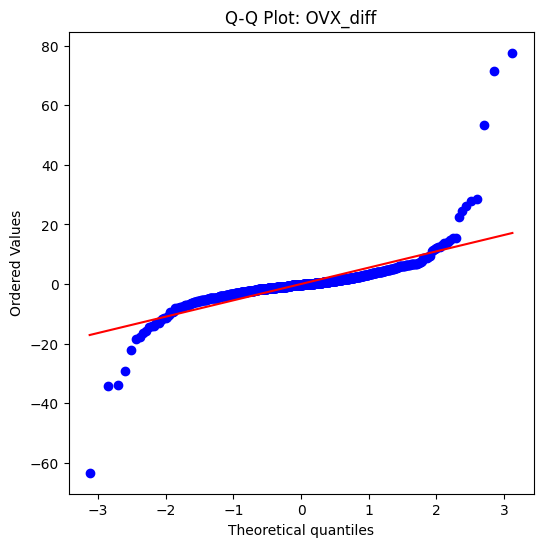

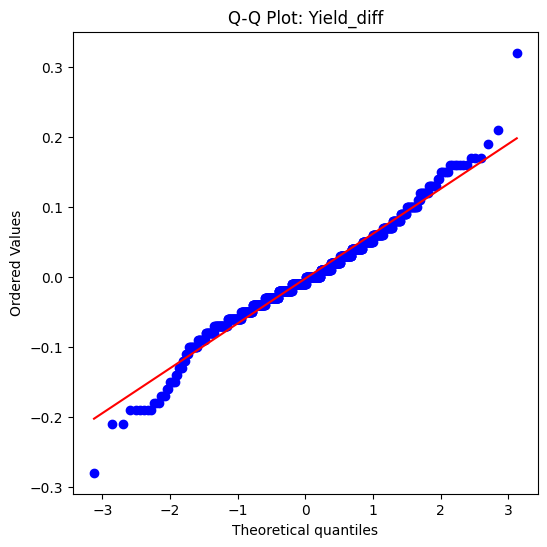

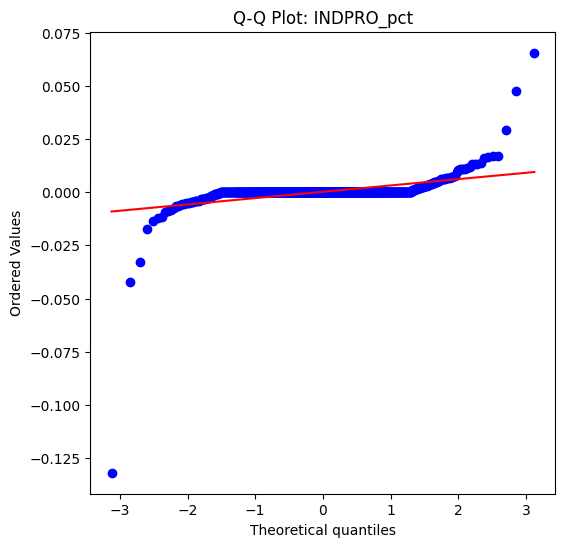

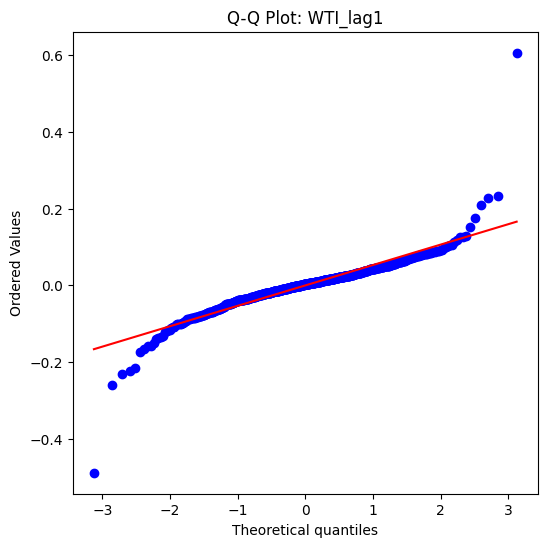

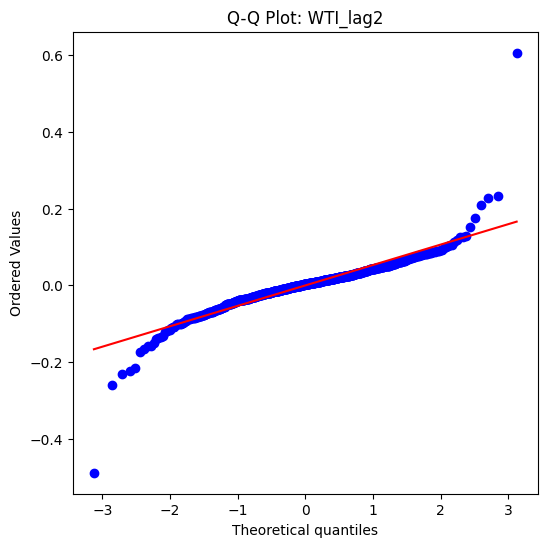

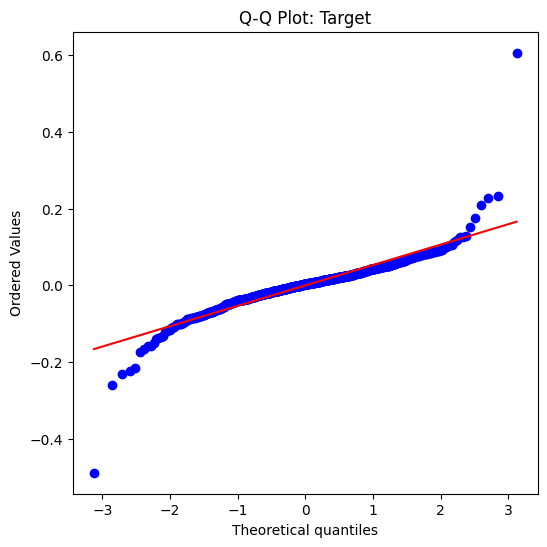

In [107]:
import scipy.stats as stats

for col in model_data.columns:
    plt.figure(figsize=(6,6))
    
    stats.probplot(model_data[col], dist="norm", plot=plt)
    
    plt.title(f'Q-Q Plot: {col}')
    plt.show()

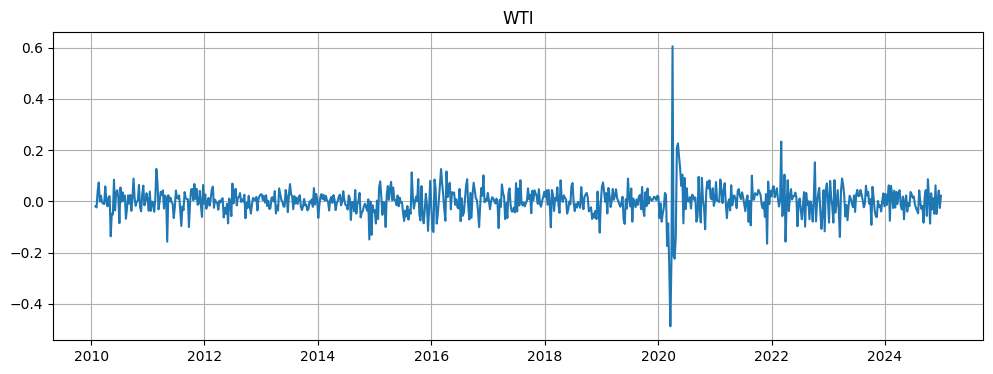

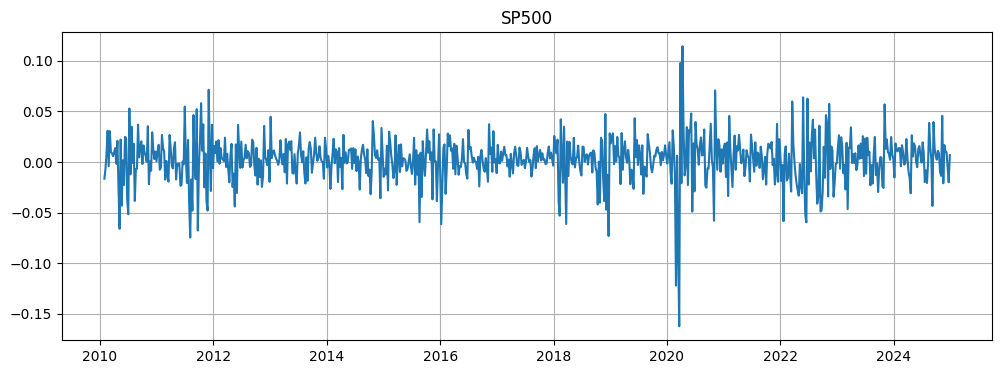

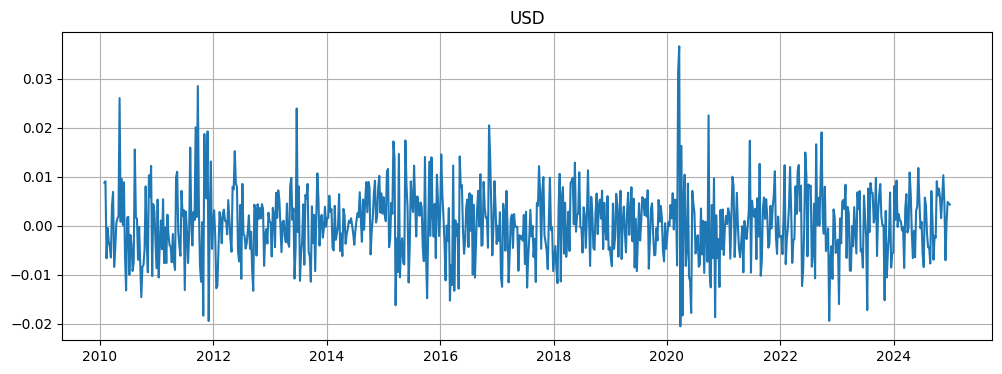

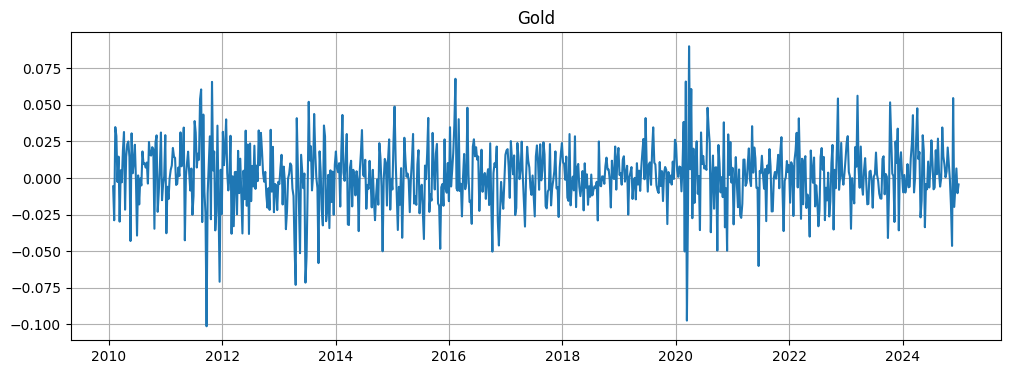

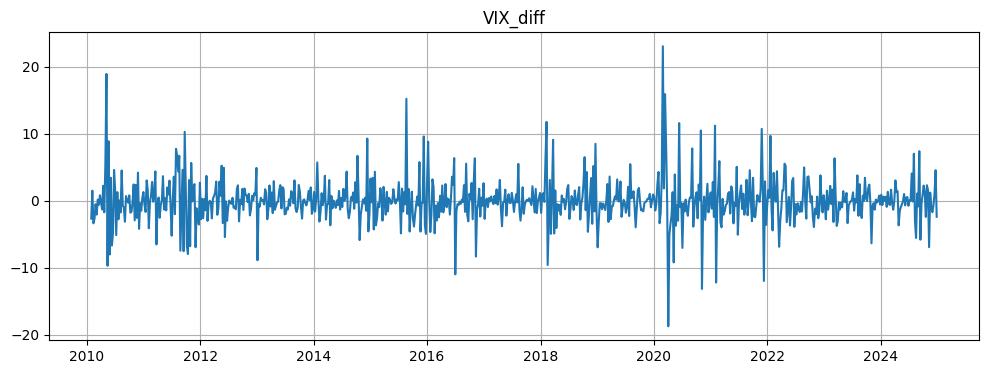

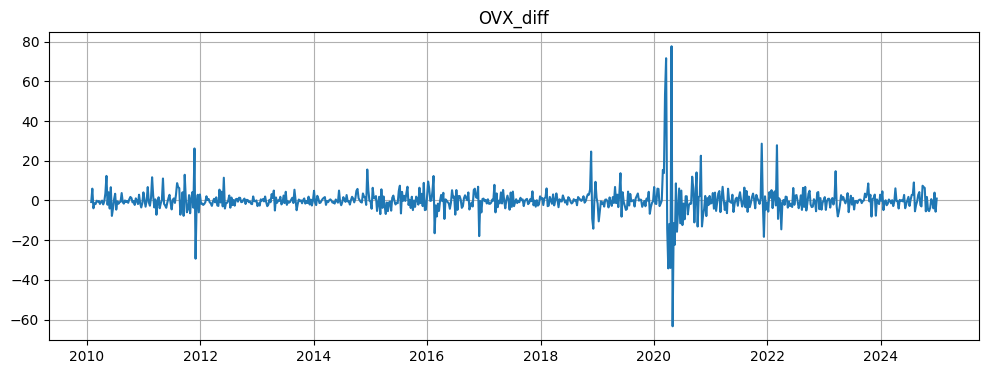

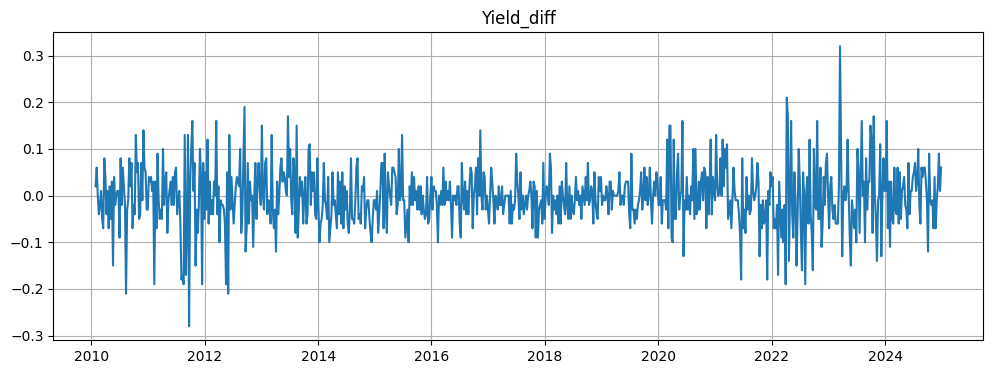

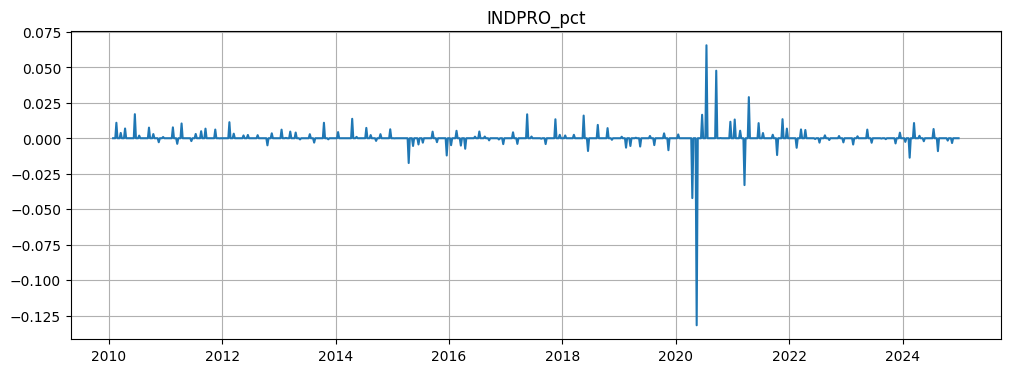

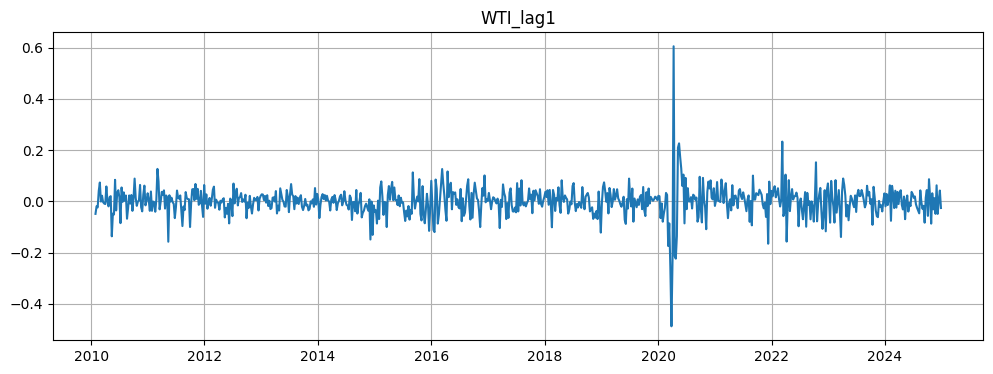

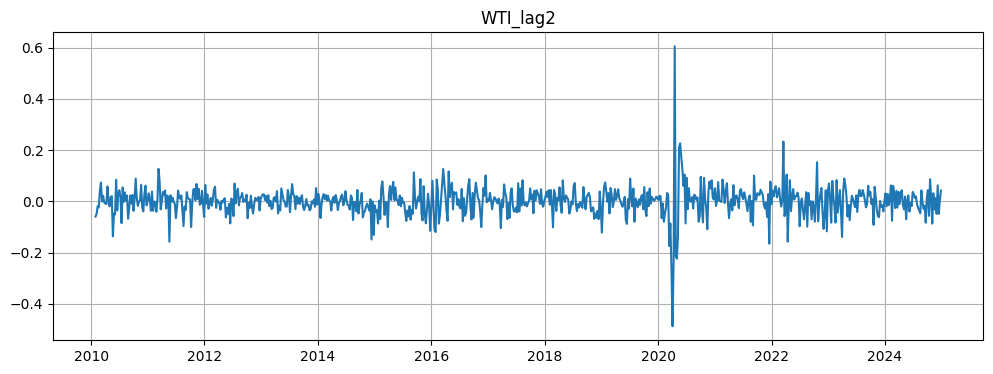

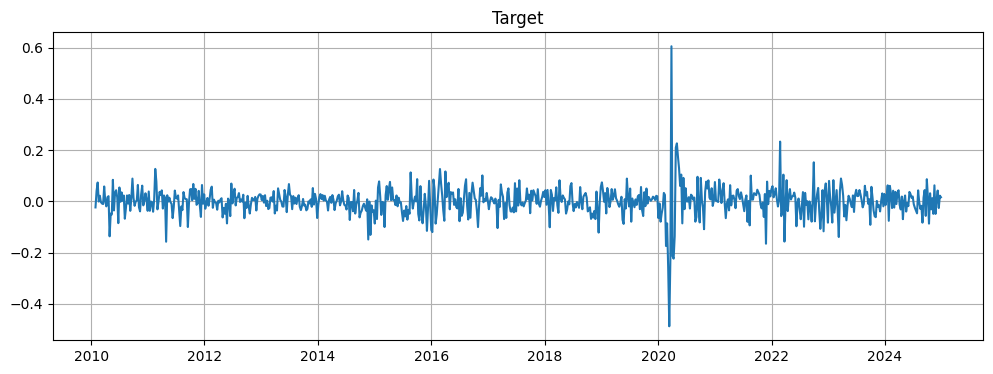

In [109]:
for col in model_data.columns:
    plt.figure(figsize=(12,4))
    
    plt.plot(model_data.index, model_data[col])
    
    plt.title(col)
    plt.grid(True)
    plt.show()

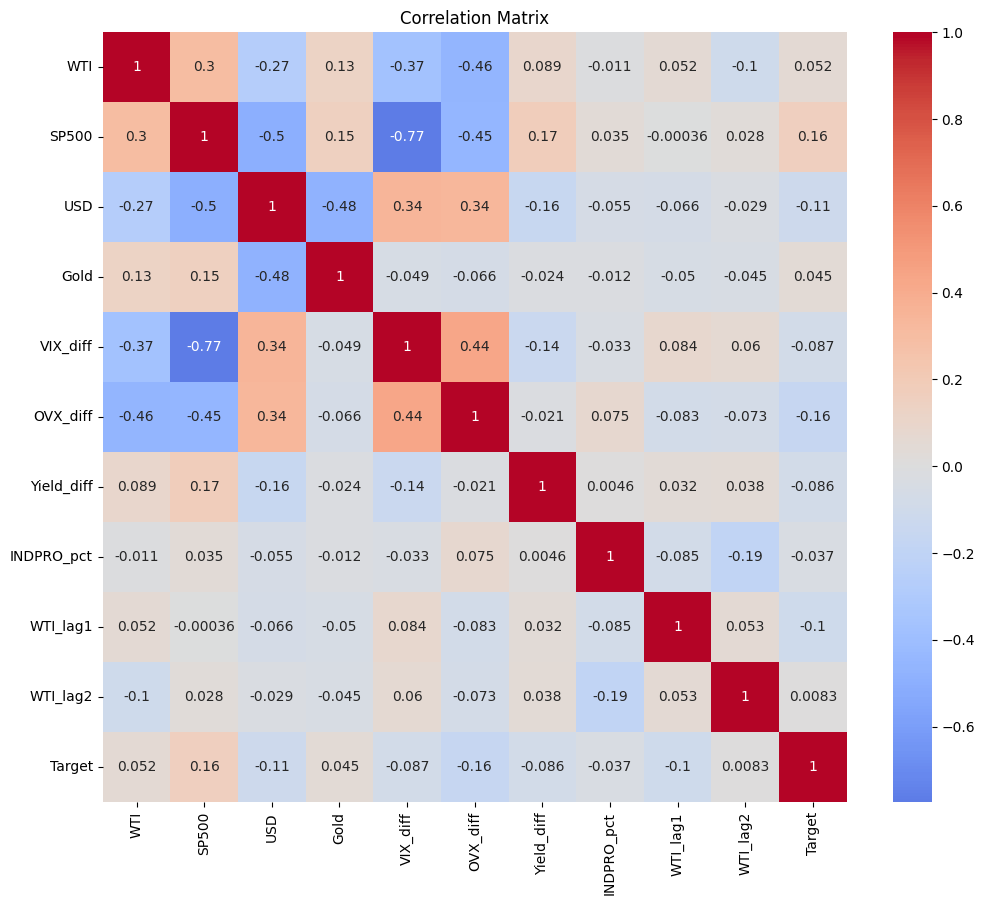

In [110]:
corr = model_data.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

In [111]:
corr['Target'].sort_values(ascending=False)

Target        1.000000
SP500         0.156089
WTI           0.051632
Gold          0.044720
WTI_lag2      0.008284
INDPRO_pct   -0.036934
Yield_diff   -0.085742
VIX_diff     -0.087081
WTI_lag1     -0.104829
USD          -0.113661
OVX_diff     -0.163843
Name: Target, dtype: float64

In [112]:
from statsmodels.tsa.stattools import adfuller

for col in model_data.columns:
    result = adfuller(model_data[col])
    
    print(f'{col}')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('---')

WTI
ADF Statistic: -9.804470031288453
p-value: 5.87606037072686e-17
---
SP500
ADF Statistic: -14.301911608349764
p-value: 1.2249772479134177e-26
---
USD
ADF Statistic: -27.33802665954312
p-value: 0.0
---
Gold
ADF Statistic: -17.491303461641603
p-value: 4.435382805774332e-30
---
VIX_diff
ADF Statistic: -12.029271400969687
p-value: 2.899608933011692e-22
---
OVX_diff
ADF Statistic: -9.175326090464566
p-value: 2.3285443755152147e-15
---
Yield_diff
ADF Statistic: -7.6817508802758026
p-value: 1.4975398413426934e-11
---
INDPRO_pct
ADF Statistic: -8.551739834538942
p-value: 9.18386224644857e-14
---
WTI_lag1
ADF Statistic: -9.78772600015278
p-value: 6.476007316105964e-17
---
WTI_lag2
ADF Statistic: -9.790946316246313
p-value: 6.356023507084714e-17
---
Target
ADF Statistic: -9.79693819942492
p-value: 6.138689091294979e-17
---


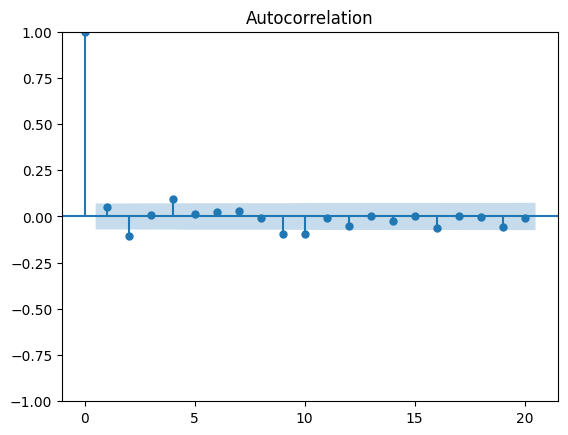

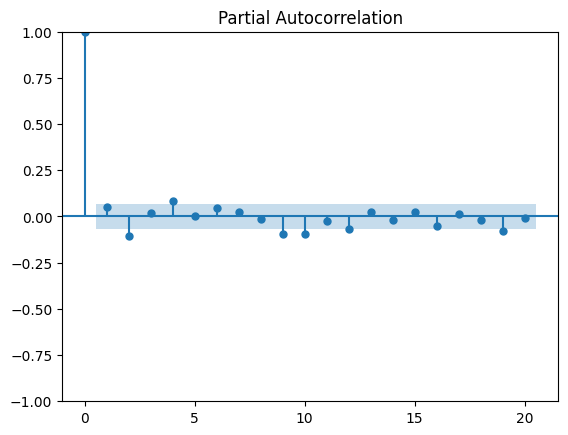

In [113]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(model_data['WTI'], lags=20)
plt.show()

plot_pacf(model_data['WTI'], lags=20)
plt.show()

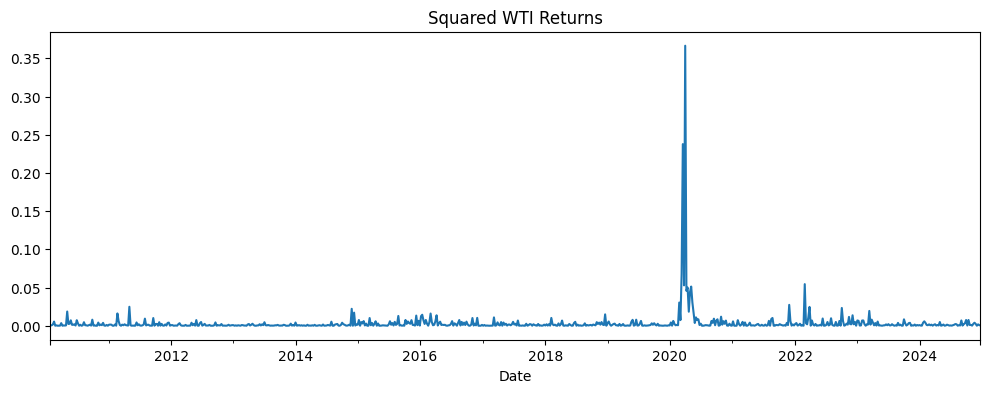

In [114]:
(model_data['WTI']**2).plot(figsize=(12,4))

plt.title('Squared WTI Returns')
plt.show()